# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

### Откройте файл с данными и изучите общую информацию

In [ ]:
#Импортируем библиотеки для операций с данными и мат. операций

In [ ]:
import matplotlib.pyplot as plt  
import pandas as pd
import math
import numpy as np

In [ ]:
#Открываем файл в нужном формате

In [ ]:
data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
pd.set_option('display.max_columns', None)

In [ ]:
#✔добавлено
#Считываем файл и выводим первые пять строчек

In [ ]:
data.info() 
print(data.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

In [ ]:
#✔добавлено
#Строим гистограмму с указанным размером

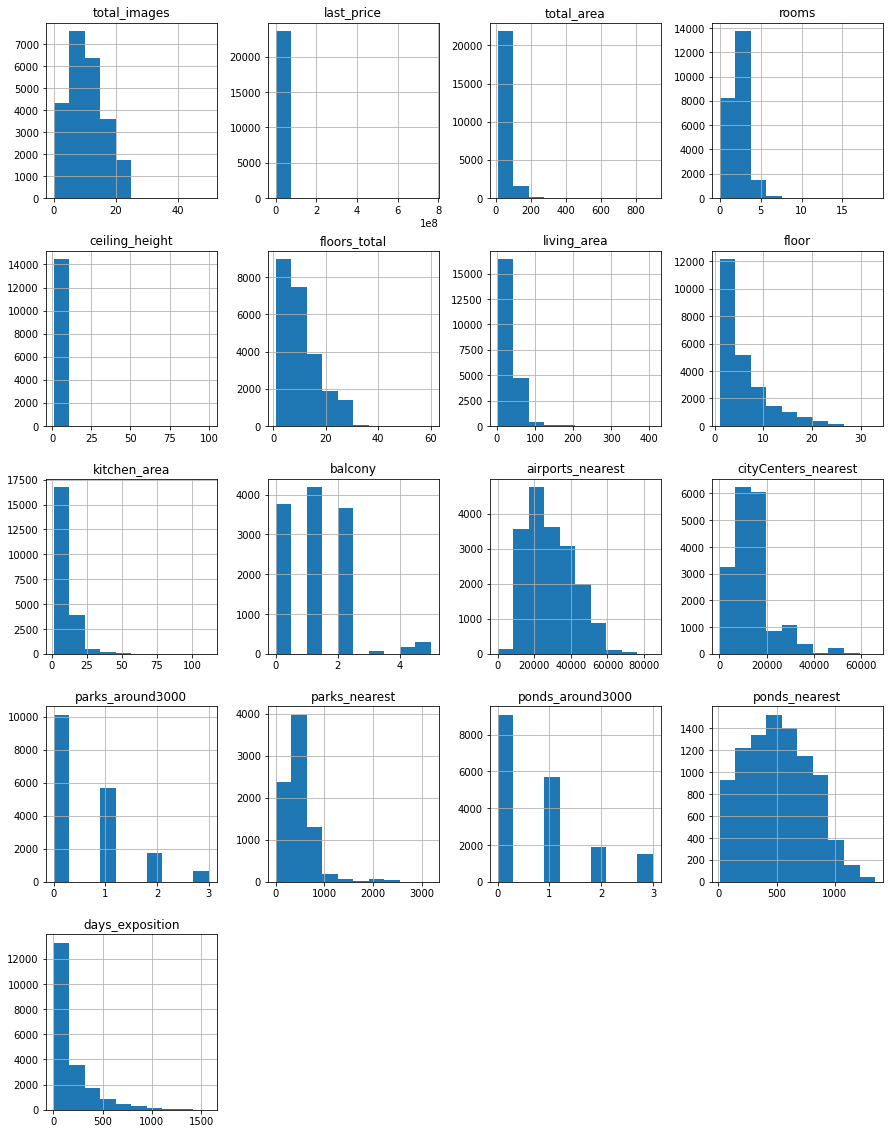

In [ ]:
data.hist(figsize=(15, 20))
plt.show()

In [ ]:

#Вывод по первоначальным данным: 
#В данных 23699 записи. 
#Есть пропущенные значения и некорректный тип данных.
#Есть аномальные значения.
#Явные дубликаты отсутствуют.

### Выполните предобработку данных

### Добавьте в таблицу новые столбцы

In [ ]:
#Поиск колличества пропущенных значений

In [ ]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

In [ ]:
#Найдите и изучите пропущенные значения в столбцах:
#Пропуски в ceiling_height,floors_total,living_area,is_apartment,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition

In [ ]:
#Смена названия столбца с cityCenters_nearest на city_centers_nearest

In [ ]:
data.rename(columns = {'cityCenters_nearest':'city_centers_nearest'}, inplace = True)
data['total_area'].round(2)
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median())

In [ ]:
#Заполните пропущенные значения там, где это возможно. Например, если продавец не указал число балконов, то, скорее всего, в его квартире их нет. Такие пропуски можно заменить на число 0. Если логичную замену предложить невозможно, то оставьте пропуски. Пропущенные значения — тоже важный сигнал, который нужно учитывать.

In [ ]:
data['balcony'].isna().sum() #11519
data['balcony'] = data['balcony'].fillna(value = 0) #замена на ноль

data['ceiling_height'].isna().sum()  #около 9000
data['ceiling_height'] = data['ceiling_height'].fillna(value = 0) #замена на пропуск

data['living_area'].isna().sum() # 1903
data['living_area'] = data['living_area'].fillna(value = 0)

data['floors_total'].isna().sum() # 86
data['floors_total'] = data['floors_total'].fillna(value = 0)

data['is_apartment'].isna().sum() #20924
data['is_apartment'] = data['is_apartment'].fillna(False)

data['kitchen_area'].isna().sum() #2278
data['kitchen_area'] = data['kitchen_area'].fillna(value = 0)

data['locality_name'].isna().sum() #49
data['locality_name'] = data['locality_name'].fillna(value = 'unknown')

data['airports_nearest'].isna().sum() #5542
data['airports_nearest'] = data['airports_nearest'].fillna(value = 0)

data['city_centers_nearest'].isna().sum() #5519

data['parks_around3000'].isna().sum() #5518
data['parks_around3000'] = data['parks_around3000'].fillna(value = 0)

data['parks_nearest'].isna().sum() #15620
data['parks_nearest'] = data['parks_nearest'].fillna(value = 0)

data['ponds_around3000'].isna().sum() #5518
data['ponds_around3000'] = data['ponds_around3000'].fillna(value = 0)

data['ponds_nearest'].isna().sum() #14589
data['ponds_nearest'] = data['ponds_nearest'].fillna(value = 0)

data['days_exposition'].isna().sum() #3181
data['ponds_nearest'] = data['ponds_nearest'].fillna(value = '')

In [ ]:
#Причины пропусков: техническая ошибка или неправильное обозначение отсутствия.(Либо дом еще в процессе стройки)

In [ ]:
#Рассмотрите типы данных в каждом столбце:Найдите столбцы, в которых нужно изменить тип данных.Преобразуйте тип данных в выбранных столбцах.

In [ ]:
data['balcony'] = data['balcony'].astype('int64')
data['last_price'] = data['last_price'].astype('int64')
data['airports_nearest'] = data['airports_nearest'].astype('int64')
data['ponds_around3000'] = data['ponds_around3000'].astype('int64')
data['parks_around3000'] = data['parks_around3000'].astype('int64')
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'])

In [ ]:
#Заполнение медианными значениями неизвестное количества этажей в доме
data['floors_total'] = data['floors_total'].fillna(0)
data['floors_total'].unique()

def floors_total(row):
    if row['floors_total'] >= 0:
        return 0
    else:
        return data[data['floor'] == row['floor']]['floors_total'].median()


In [ ]:
#Пояснение:время не очень было удобно воспринимать, количество чего то было в формате float, что странно. Так же в типе жилья не было bool

In [ ]:
#Изучите уникальные значения в столбце с названиями и устраните неявные дубликаты. Например, «поселок Рябово» и «поселок городского типа Рябово», «поселок Тельмана» и «посёлок Тельмана» — это обозначения одних и тех же населённых пунктов. Вы можете заменить названия в существующем столбце или создать новый с названиями без дубликатов.

In [ ]:
data['locality_name'] = data['locality_name'].str.replace('поселок', 'посёлок')
data['locality_name'] = data['locality_name'].str.replace('городской','')
data['locality_name'] = data['locality_name'].str.replace('садовое','')
data['locality_name'] = data['locality_name'].str.replace('станции','')
data['locality_name'] = data['locality_name'].str.replace('коттеджный','')

In [ ]:
#Проверка на уникальные названия

In [ ]:
print(data.duplicated().sum())
data['locality_name'].unique()

0


array(['Санкт-Петербург', 'посёлок Шушары', ' посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'посёлок городского типа Красный Бор', 'Гатчина',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'посёлок Молодцово',
       'посёлок городского типа Кузьмоловский',
       ' товарищество Новая Ропша', 'Павловск', 'деревня Пикколово',
       'Всеволожск', 'Волхов', 'Кингисепп', 'Приозерск', 'Сестрорецк',
       'деревня Куттузи', 'посёлок Аннино',
       'посёлок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'посёлок Торковичи', 'посёлок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', 'посёлок Новый Свет', 'Сланцы',
   

In [ ]:
#Обязательно ли нам заполнять все пропуски 0 или пустой строкой? Какие преимущества это нам даст?
#Чтобы было удобнее работать с данными и использовать функции и строить графики.
#✔добавлено

In [ ]:
#Добавление столбцов: год,месяц,день публикации. 

In [ ]:
data['year_publication'] = data['first_day_exposition'].dt.year 
data['year_publication'].unique()
data['month_publication'] = data['first_day_exposition'].dt.month 
data['month_publication'].unique()
data['day_publication'] = data['first_day_exposition'].dt.weekday 
data['day_publication'].unique()

array([3, 1, 4, 0, 2, 6, 5])

In [ ]:
#Определение категории этажа:первый, последний или другой

In [ ]:
def floor(row):
    if row['floor'] == 1:
        return 'первый'
    if row['floor'] == row['floors_total']:
        return 'последний'
    else:
        return 'другой'

data['type_apartment_floor'] = data.apply(floor, axis=1)

In [ ]:
#Цена за квадратный метр

In [ ]:
data['price_square_meter'] = (data['last_price'] / data['total_area']).round(2)
data['price_square_meter'].unique()

array([120370.37,  82920.79,  92785.71, ...,  44091.71, 149511.4 ,
        41795.67])

In [ ]:
#Изменение типа столбца и округление

In [ ]:
data['city_centers_nearest'] = data['city_centers_nearest'].astype(float)
data['city_centers_nearest'].round(2)

0        16028.0
1        18603.0
2        13933.0
3         6800.0
4         8098.0
          ...   
23694     4232.0
23695        NaN
23696        NaN
23697    10364.0
23698        NaN
Name: city_centers_nearest, Length: 23699, dtype: float64

In [ ]:
#Расстояние до центра города.
data['distance_city_center'] = (data['city_centers_nearest'] / 1000).round(0)
data['distance_city_center'].unique()

array([16., 19., 14.,  7.,  8., nan, 12., 15., 52., 33., 31., 11., 13.,
       10.,  2., 32.,  4., 17., 30.,  5., 51., 50., 24., 18.,  9., 28.,
        3.,  6., 27., 21., 49., 35., 36., 34.,  1., 29., 26., 53., 22.,
       55., 20., 23., 25.,  0., 66., 47., 40., 57., 37., 41., 43., 48.,
       62., 60., 39., 42., 65., 54., 59., 45., 61., 63.])

In [ ]:

#Вывод:

#Переименован cityCenters_nearest на city_centers_nearest.
#Заполнены пропуски в таблице, округлены значения.
#Изменен тип данных.

#Вывод о причинах появления пропусков:
        #Человеческий фактор.
        #Возможен технический сбой.
        
#Добавлены новые столбцы:
    #price_square_meter - цена квадратного метра объекта с округлением до двух знаков.
    #distance_city_center - расстояние до центра города.
    #day_publication - день недели публикации.
    #month_publication - месяц публикации.
    #year_publication - год публикации.
    #type_apartment_floor - тип этажа квартиры.

### Проведите исследовательский анализ данных

In [ ]:
#Изучение и описание параметров:

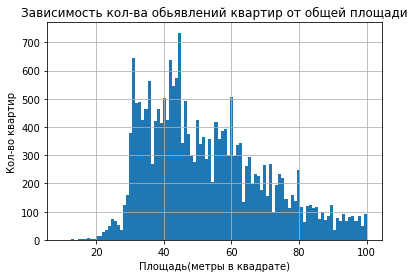

In [ ]:
#Общая площадь.Анализ
data['total_area'].describe()
data['total_area'].hist(bins=100, range=(10,100))
plt.title('Зависимость кол-ва обьявлений квартир от общей площади')
plt.xlabel('Площадь(метры в квадрате)')
plt.ylabel('Кол-во квартир')
plt.show()
#Вывод: Рассматривают в основном 25-60квм. Максимальное кол-во обьявлений -45квм

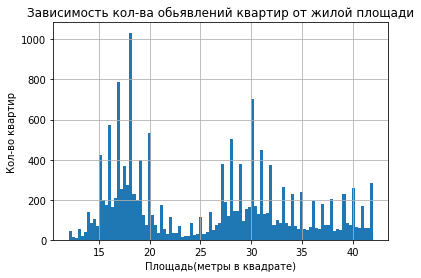

In [ ]:
#Жилая площадь.Анализ
data['living_area'].describe()
data['living_area'].hist(bins=100, range=(12,42))
plt.title('Зависимость кол-ва обьявлений квартир от жилой площади')
plt.xlabel('Площадь(метры в квадрате)')
plt.ylabel('Кол-во квартир')
plt.show()
#Вывод: Рассматривают в основном 18 либо около 32квм.

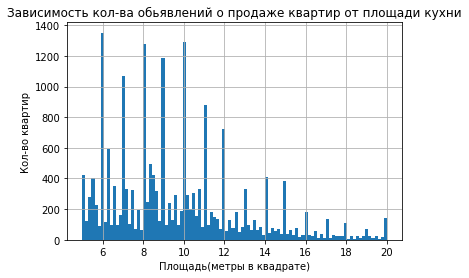

In [ ]:
#Площадь кухни.Анализ
data['kitchen_area'].describe()
data['kitchen_area'].hist(bins=100, range=(5,20))
plt.title('Зависимость кол-ва обьявлений о продаже квартир от площади кухни')
plt.xlabel('Площадь(метры в квадрате)')
plt.ylabel('Кол-во квартир')
plt.show()
#Вывод: Рассматривают в основном с кухней в 6,8,10 метров

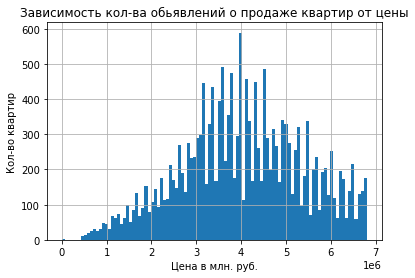

In [ ]:
#Цена.Анализ
data['last_price'].describe()
data['last_price'].hist(bins=100, range=(1.219000e+04,6.800000e+06))
plt.title('Зависимость кол-ва обьявлений о продаже квартир от цены')
plt.xlabel('Цена в млн. руб.')
plt.ylabel('Кол-во квартир')
plt.show()
#Вывод: Рассматривают в основном с ценой 3.2-4.5млн.р

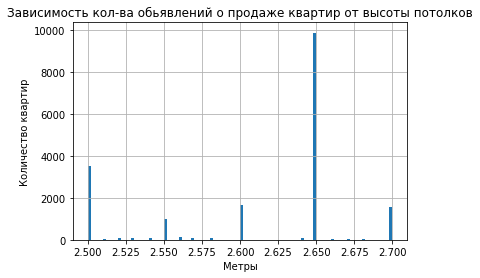

In [ ]:
#Высота потолков.Анализ
data['ceiling_height'].describe()
data['ceiling_height'].hist(bins=100, range=(2.5,2.7))
plt.title('Зависимость кол-ва обьявлений о продаже квартир от высоты потолков')
plt.xlabel('Метры')
plt.ylabel('Количество квартир')
plt.show()
#Вывод: Рассматривают в основном с потолком 2.65м

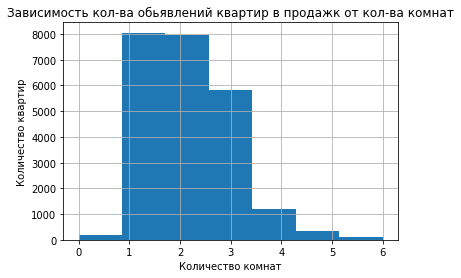

In [ ]:
#Количество комнат.Анализ
data['rooms'].hist( bins=7, range=(0,6))
plt.title('Зависимость кол-ва обьявлений квартир в продажк от кол-ва комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Количество квартир')
plt.show()
#Вывод: Рассматривают в основном однокомнатные и двухкомнатные.

In [ ]:
# Количество объявлений по каждому типу этажа.

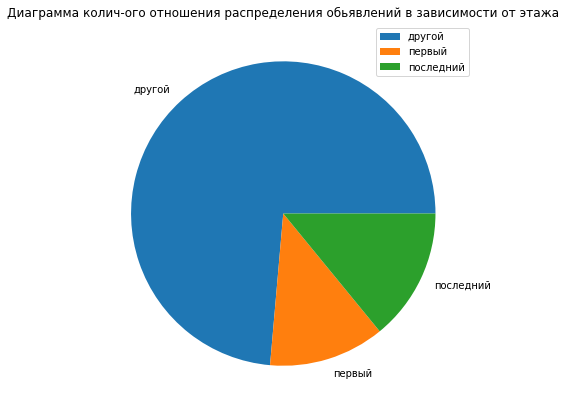

In [ ]:
data.pivot_table(index='type_apartment_floor',values='last_price',aggfunc='count') \
  .plot.pie(y='last_price', figsize=(10,7), label='', title='Диаграмма колич-ого отношения распределения обьявлений в зависимости от этажа')
plt.show()

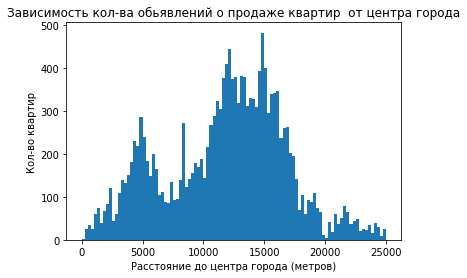

In [ ]:
#Расстояние до центра города в метрах.Анализ
data['city_centers_nearest'].describe()
plt.hist(data['city_centers_nearest'], bins=100, range=(0,25000))
plt.title('Зависимость кол-ва обьявлений о продаже квартир  от центра города')
plt.xlabel('Расстояние до центра города (метров)')
plt.ylabel('Кол-во квартир')
plt.show()

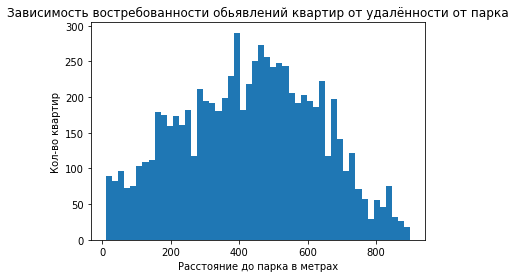

In [ ]:
#Расстояние до ближайшего парка.Анализ
data['parks_nearest'].describe()
plt.hist(data['parks_nearest'], bins=50, range=(10,900))
plt.title('Зависимость востребованности обьявлений квартир от удалённости от парка')
plt.xlabel('Расстояние до парка в метрах')
plt.ylabel('Кол-во квартир')
plt.show()
#Вывод: Востребованноть обьявлений несильно зависят от удаленности от парка

count    20518.000000
mean       180.888634
std        219.727988
min          1.000000
25%         45.000000
50%         95.000000
75%        232.000000
max       1580.000000
Name: days_exposition, dtype: float64


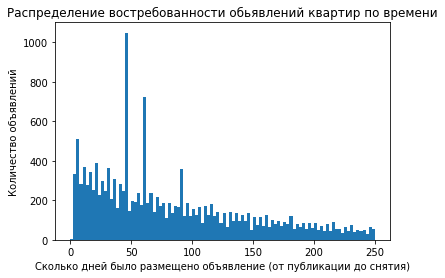

In [ ]:
#Продажи в зависимости от времени.Анализ.Как быстро продавались квартиры (столбец days_exposition):
print(data['days_exposition'].describe())
plt.hist(data['days_exposition'], bins=100, range=(0,250))
plt.title('Распределение востребованности обьявлений квартир по времени')
plt.xlabel('Сколько дней было размещено объявление (от публикации до снятия)')
plt.ylabel('Количество объявлений')
plt.show()
#Вывод: в среднем снятие публикации обьявления занимает 2-3 месяца.

In [ ]:
#Cредняя цена одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений:
price_mq_name = data.pivot_table(index='locality_name', values='last_price', aggfunc=['count'])
price_mq_name.columns = ['count']
price_mq_name = price_mq_name.sort_values(by='count', ascending=False).head(10)
price_mq_name['price_square_meter'] = data.pivot_table(index='locality_name', values='price_square_meter').round(2)
price_mq_name.sort_values(by='price_square_meter', ascending=False)
#Вывод: наибольшая средняя стоимость - Санкт-Петербург и Пушкин.

,count,price_square_meter
locality_name,,
Санкт-Петербург,15721,114849.01
Пушкин,369,103125.82
деревня Кудрово,299,92473.55
посёлок Парголово,327,90175.91
посёлок Мурино,556,85681.76
посёлок Шушары,440,78677.36
Колпино,338,75424.58
Гатчина,307,68746.15
Всеволожск,398,68654.47


In [ ]:
print(data['days_exposition'].describe())

count    20518.000000
mean       180.888634
std        219.727988
min          1.000000
25%         45.000000
50%         95.000000
75%        232.000000
max       1580.000000
Name: days_exposition, dtype: float64


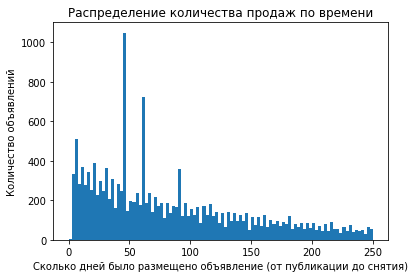

In [ ]:
plt.hist(data['days_exposition'], bins=100, range=(0,250))
plt.title('Распределение количества продаж по времени')
plt.xlabel('Сколько дней было размещено объявление (от публикации до снятия)')
plt.ylabel('Количество объявлений')
plt.show()

In [ ]:
#Медианное время продажи квартиры составляет 95 дней — этот показатель лучше отражает реальную ситуацию,
#так как не зависит от выбросов. В среднем продажа занимает 2–3 месяца, в зависимости от площади, цены и удалённости от центра.

#Быстрые - около 45 дней, долгие - более 232 дней.

In [ ]:
print('Корреляция:','\n')
print(data.pivot_table(index='floor', values=['last_price','total_area','living_area','kitchen_area','rooms','day_publication','month_publication','year_publication']).corr(),'\n')
print('Корреляция:','\n')
print(data.pivot_table(index='floor', values=['last_price','total_area','living_area','kitchen_area','rooms']).corr(),'\n')

Корреляция: 

                   day_publication  kitchen_area  last_price  living_area  \
day_publication           1.000000      0.551975    0.323738     0.193165   
kitchen_area              0.551975      1.000000    0.284824     0.244869   
last_price                0.323738      0.284824    1.000000     0.621699   
living_area               0.193165      0.244869    0.621699     1.000000   
month_publication         0.269221     -0.009482   -0.019113    -0.136600   
rooms                    -0.059111      0.177180    0.442449     0.893732   
total_area                0.320962      0.454583    0.738972     0.947346   
year_publication          0.181063     -0.254011   -0.052080    -0.026356   

                   month_publication     rooms  total_area  year_publication  
day_publication             0.269221 -0.059111    0.320962          0.181063  
kitchen_area               -0.009482  0.177180    0.454583         -0.254011  
last_price                 -0.019113  0.442449    0.738

In [ ]:
# Функция для подсчёта границ с 1.5 размаха

def quartile_range(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    dataq = data.loc[(data[column] < q3 + 1.5*iqr) & (data[column] > q1 - 1.5*iqr), column]
    return dataq
# Столбцы с выбросами
list_features = ['last_price', 'total_area', 'living_area', 'kitchen_area', 'rooms', 'ceiling_height' ]
for col in list_features:
    data[col] = quartile_range(data, col)
    
print('Корреляция:','\n')
print(data.pivot_table(index='floor', values=['last_price','total_area','living_area','kitchen_area','rooms']).corr(),'\n')

Корреляция: 

              kitchen_area  last_price  living_area     rooms  total_area
kitchen_area      1.000000    0.507438     0.048675 -0.132606    0.342559
last_price        0.507438    1.000000     0.794102  0.551637    0.905255
living_area       0.048675    0.794102     1.000000  0.876403    0.950896
rooms            -0.132606    0.551637     0.876403  1.000000    0.786100
total_area        0.342559    0.905255     0.950896  0.786100    1.000000 



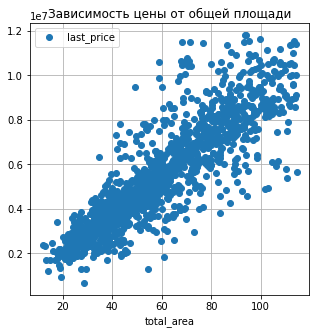

In [ ]:
(
    data.pivot_table(index='total_area', values='last_price')
    .plot(grid=True, style='o', figsize=(5, 5))
)
plt.title('Зависимость цены от общей площади')
plt.show()

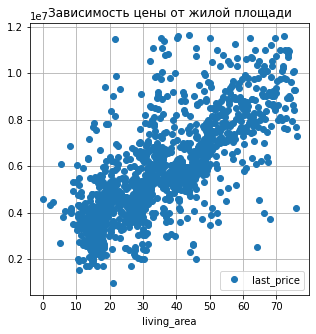

In [ ]:
(
    data.pivot_table(index='living_area', values='last_price')
    .plot(grid=True, style='o', figsize=(5, 5))
)
plt.title('Зависимость цены от жилой площади')
plt.show()

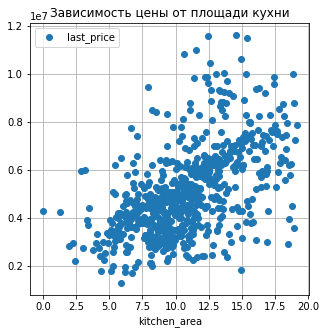

In [ ]:
(
    data.pivot_table(index='kitchen_area', values='last_price')
    .plot(grid=True, style='o', figsize=(5, 5))
)
plt.title('Зависимость цены от площади кухни')
plt.show()

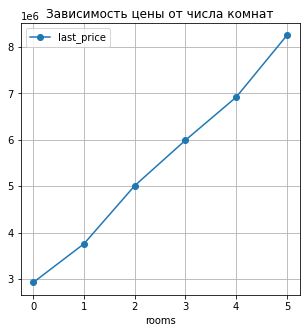

In [ ]:
(
    data.pivot_table(index='rooms', values='last_price')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.title('Зависимость цены от числа комнат')
plt.show()

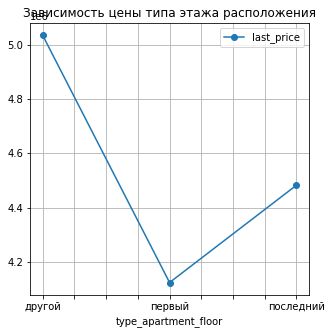

In [ ]:
(
    data.pivot_table(index='type_apartment_floor', values='last_price')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.title('Зависимость цены типа этажа расположения')
plt.show()

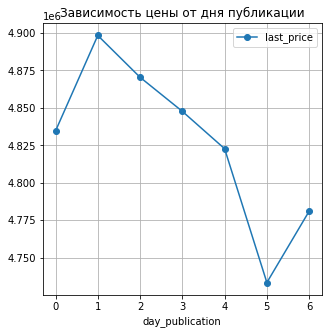

In [ ]:
(
    data.pivot_table(index='day_publication', values='last_price')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.title('Зависимость цены от дня публикации')
plt.show()

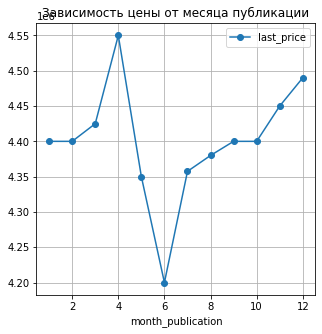

In [ ]:
(
    data.pivot_table(index='month_publication', values='last_price', aggfunc='median')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.title('Зависимость цены от месяца публикации')
plt.show()

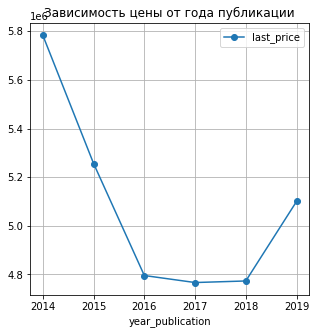

In [ ]:
(
    data.pivot_table(index='year_publication', values='last_price')
    .plot(grid=True, style='o-', figsize=(5, 5))
)
plt.title('Зависимость цены от года публикации')
plt.show()

In [ ]:
#Вывод

# Медианное время продажи квартиры составляет 95 дней — этот показатель лучше отражает реальную ситуацию,
# так как не зависит от выбросов. В среднем продажа занимает 2–3 месяца, в зависимости от площади, цены и удалённости от центра.

# Чем больше общая площадь квартиры, тем выше её стоимость — между этими параметрами наблюдается очень сильная корреляция.
# Количество комнат также влияет на цену, но эта зависимость слабее, поскольку встречаются квартиры с небольшим числом комнат,
# но большой площадью, а также дорогие квартиры в центре с малым количеством комнат.

# Квартиры на первом этаже обычно стоят заметно дешевле, чуть дороже — на последнем этаже. 
# Самые высокие цены у квартир, расположенных между первым и последним этажами.

In [ ]:
#Выделим квартиры в Санкт-Петербурге с помощью столбца locality_name и вычислим их среднюю стоимость на разном удалении от центра

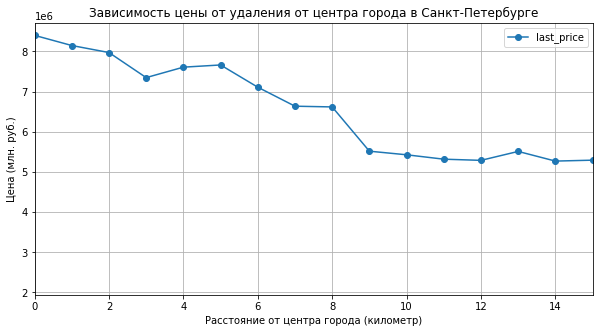

Таблица средней стоимости квартир в зависимости от удаления центра города Санкт-Петербург


,last_price
distance_city_center,
0.0,8.398000e+06
1.0,8.145277e+06
2.0,7.970519e+06
3.0,7.346575e+06
4.0,7.606618e+06
5.0,7.661225e+06
6.0,7.108234e+06
7.0,6.635321e+06
8.0,6.617244e+06


In [ ]:
data.query('locality_name == "Санкт-Петербург"')['distance_city_center'].describe()
(
    data.query('locality_name == "Санкт-Петербург"')
    .pivot_table(index='distance_city_center', values='last_price')
    .plot(grid=True, style='o-', xlim=(0,15), figsize=(10, 5))
)

plt.title('Зависимость цены от удаления от центра города в Санкт-Петербурге')
plt.xlabel('Расстояние от центра города (километр)')
plt.ylabel('Цена (млн. руб.)')
plt.show()
print('Таблица средней стоимости квартир в зависимости от удаления центра города Санкт-Петербург')
data.query('locality_name == "Санкт-Петербург" and distance_city_center<10').pivot_table(values='last_price', index='distance_city_center')

In [ ]:
# Описание среднестатистического востребованного обьявления:

    # Среднестатистическая квартира — это жильё площадью около 52 кв. метров.
    # Кухня обычно занимает 6 кв. метров, а высота потолков составляет 2,65 метра.
    # Чаще всего это однокомнатная или двухкомнатная квартира с небольшими комнатами,
    # расположенная на расстоянии 5–13 км от центра города.

#Анализ скорости продажи квартир.

# Изучена динамика продаж:

    # среднее время продажи квартиры составляет 180 дней, 
    # однако медианное значение — 95 дней, 
    # что более точно отражает типичную ситуацию,
    # поскольку меньше подвержено влиянию выбросов.
    
# В среднем продажа стандартной квартиры занимает 2–3 месяца, в зависимости от таких факторов, как:

    # Площадь.
    # Цена.
    # Удалённость от центра.

# Быстрая продажа: если квартира продаётся за 45 дней (первый квартиль).
# Долгая продажа: если продажа занимает 232 дня и более (третий квартиль) — такие объекты могут не продаваться.

# Ключевые факторы, влияющие на стоимость квартиры.

    # Общая площадь: чем больше площадь квартиры, тем выше её стоимость.
    # Число комнат: больше комнат — выше цена, однако эта зависимость менее выражена, чем у площади, поскольку встречаются квартиры с разным распределением жилой площади.
    # Этаж расположения: квартиры на первом этаже, как правило, дешевле остальных; немного дороже — на последнем этаже. Максимальную стоимость имеют квартиры, расположенные не на первом и не на последнем этажах.

# Средняя стоимость квадратного метра по населённым пунктам.

    # Наибольшая средняя цена квадратного метра — в Санкт-Петербурге. Далее следует Пушкин, что объясняется развитой инфраструктурой и большим количеством зелёных зон. Остальные лидеры — районы, непосредственно примыкающие к Санкт-Петербургу. Самая низкая стоимость квадратного метра среди топ-10 наблюдается в Гатчине, Всеволожске (из-за удалённости от города) и в небольшом по численности населения Выборге, который расположен далеко от Санкт-Петербурга.

#Стоимость квартир в зависимости от расстояния до центра:

    # Самые дорогие квартиры находятся в центре Санкт-Петербурга.
    # По мере удаления от центра до 7 км стоимость жилья постепенно уменьшается, после чего эта зависимость практически исчезает.

### Напишите общий вывод
 В данных 23699 записи
 Дубликатов нет, но есть разница в написании населенного пункта
 Есть пропущенные значения, которые исправлены
 Изменены типы данных, изменено представление времени
 Добавлены столбцы с датами публикаций и названиям этажей
 Определены параметры квартир и их продаваемости

**Чек-лист готовности проекта**

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Файл с данными открыт.
- [ ]  Файл с данными изучен: выведены первые строки, использован метод `info()`, построены гистограммы.
- [ ]  Найдены пропущенные значения.
- [ ]  Пропущенные значения заполнены там, где это возможно.
- [ ]  Объяснено, какие пропущенные значения обнаружены.
- [ ]  В каждом столбце установлен корректный тип данных.
- [ ]  Объяснено, в каких столбцах изменён тип данных и почему.
- [ ]  Устранены неявные дубликаты в названиях населённых пунктов.
- [ ]  Обработаны редкие и выбивающиеся значения (аномалии).
- [ ]  В таблицу добавлены новые параметры:
       – цена одного квадратного метра;
       – день публикации объявления (0 - понедельник, 1 - вторник и т. д.);
       – месяц публикации объявления;
       – год публикации объявления;
       – тип этажа квартиры (значения — «первый», «последний», «другой»);
       – расстояние до центра города в километрах.
- [ ]  Изучены и описаны параметры:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - цена объекта;
        - количество комнат;
        - высота потолков;
        - тип этажа квартиры («первый», «последний», «другой»);
        - общее количество этажей в доме;
        - расстояние до центра города в метрах;
        - расстояние до ближайшего парка.
- [ ]  Выполнено задание «Изучите, как быстро продавались квартиры (столбец `days_exposition`)»:
    - построена гистограмма;
    - рассчитаны среднее и медиана;
    - описано, сколько обычно занимает продажа и указано, какие продажи можно считать быстрыми, а какие — необычно долгими.
- [ ]  Выполнено задание «Определите факторы, которые больше всего влияют на общую (полную) стоимость объекта». Построены графики, которые показывают зависимость цены от параметров:
        - общая площадь;
        - жилая площадь;
        - площадь кухни;
        - количество комнат;
        - тип этажа, на котором расположена квартира (первый, последний, другой);
        - дата размещения (день недели, месяц, год).
- [ ]  Выполнено задание «Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений»:
    - выделены населённые пункты с самой высокой и низкой стоимостью квадратного метра.
- [ ]  Выполнено задание «Выделите квартиры в Санкт-Петербурге с помощью столбца `locality_name` и вычислите их среднюю стоимость на разном удалении от центра»:
    -  учтён каждый километр расстояния, известны средние цены квартир в одном километре от центра, в двух и так далее;
    -  описано, как стоимость объекта зависит от расстояния до центра города;
    -  построен график изменения средней цены для каждого километра от центра Петербурга.
- [ ]  На каждом этапе сделаны промежуточные выводы.
- [ ]  В конце проекта сделан общий вывод.